# Notebook 2 – Regularization

## What is Regularization?
Regularization is a technique used in machine learning to prevent **overfitting** by adding a penalty term to the cost function. This penalty discourages the model from learning overly complex patterns (i.e., having very large coefficients), which helps the model generalize better to unseen data.

### Why Regularization?
When a model is too complex, it starts to "memorize" the noise in the training data rather than the actual underlying pattern. This leads to high variance. Regularization introduces a "bias" to the model to reduce this variance, effectively trading off a small amount of training accuracy for a significant increase in test accuracy.

### The Regularization Parameter ($\lambda$ or $\alpha$)
The strength of the regularization is controlled by a hyperparameter $\lambda$ (in Scikit-learn, this is typically $\alpha$).
- If $\lambda = 0$, the model is equivalent to standard Linear Regression.
- If $\lambda$ is very large, the coefficients are pushed closer to zero, potentially leading to underfitting.

## Types of Regularization

### 1. L1 Regularization (Lasso Regression)
L1 adds the **absolute value** of the magnitude of coefficients as a penalty term to the cost function:
$$\text{Cost} = \text{MSE} + \lambda \sum_{j=1}^{n} |\beta_j|$$
- **Feature Selection:** Lasso can shrink some coefficients exactly to **zero**. This effectively removes irrelevant features from the model, performing built-in feature selection.

### 2. L2 Regularization (Ridge Regression)
L2 adds the **squared magnitude** of coefficients as a penalty term:
$$\text{Cost} = \text{MSE} + \lambda \sum_{j=1}^{n} \beta_j^2$$
- **Weight Decay:** Ridge shrinks coefficients toward zero but almost never makes them exactly zero. It is better when you have many features that all contribute a small amount to the target.

### 3. Elastic Net
Elastic Net is a hybrid approach that combines both L1 and L2 penalties:
$$\text{Cost} = \text{MSE} + \lambda_1 \sum |\beta_j| + \lambda_2 \sum \beta_j^2$$
- It is useful when there are multiple correlated features; Lasso tends to pick one randomly, while Ridge spreads the weight. Elastic Net provides a balance.

## Summary: L1 vs L2 vs Elastic Net

| Feature | L1 (Lasso) | L2 (Ridge) | Elastic Net |
| :--- | :--- | :--- | :--- |
| **Penalty** | $\sum |\beta|$ | $\sum \beta^2$ | $\text{L1} + \text{L2}$ |
| **Solution** | Sparse (some $\beta=0$) | Dense (all $\beta \neq 0$) | Hybrid |
| **Use Case** | Feature Selection | Reducing Overfitting | Correlated Features |
| **Model Complexity**| Reduces number of features | Reduces magnitude of weights | Balanced |

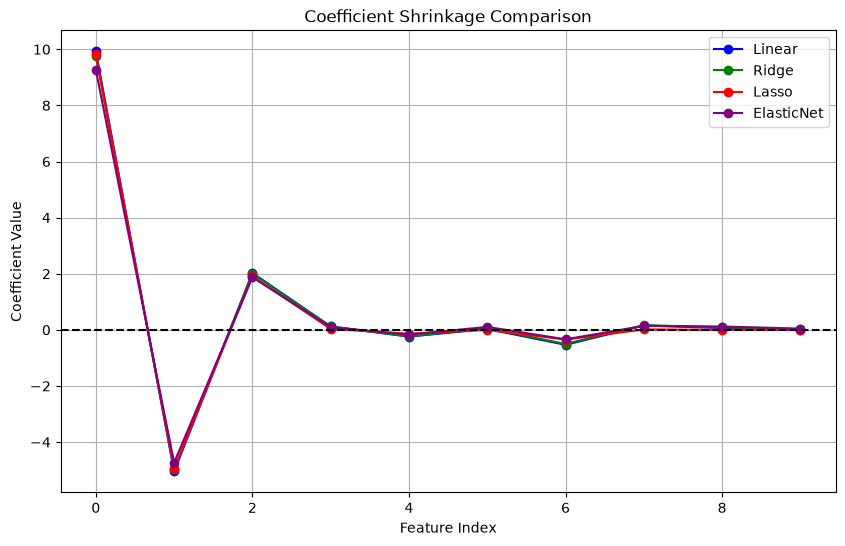

Lasso Coefficients:
 [ 9.82318197 -4.95556567  1.90828363  0.03401208 -0.14000183  0.
 -0.34617166  0.01486063  0.          0.        ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create a synthetic dataset with some irrelevant features
np.random.seed(42)
X = np.random.randn(100, 10) # 10 features
# Only first 3 features are actually useful
true_beta = np.array([10, -5, 2, 0, 0, 0, 0, 0, 0, 0])
y = np.dot(X, true_beta) + np.random.randn(100) * 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression (No Regularization)
lr = LinearRegression().fit(X_train, y_train)
# 2. Ridge (L2)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
# 3. Lasso (L1)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
# 4. Elastic Net
en = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_train, y_train)

# Compare coefficients
coefs = np.array([lr.coef_, ridge.coef_, lasso.coef_, en.coef_])

plt.figure(figsize=(10, 6))
plt.plot(coefs[0], 'o-', label='Linear', color='blue')
plt.plot(coefs[1], 'o-', label='Ridge', color='green')
plt.plot(coefs[2], 'o-', label='Lasso', color='red')
plt.plot(coefs[3], 'o-', label='ElasticNet', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Coefficient Shrinkage Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True)
plt.show()

print("Lasso Coefficients:\n", lasso.coef_) # Note how many are exactly 0